In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import statsmodels.tsa.api as smt

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [3]:
df = pd.read_csv(r'C:\CODE\python projects\sir\Medicine-Sales-Analysis-Dashboard-with-Future-Business-Predictions\csv\Mfg_Sales.csv')

In [4]:
print(df.head())

        AcYr   MMYYYY  Zone BranchName  MKTType                    BrandName  \
0  2020-2021  2020-04  EAST    CUTTACK  PILLAR             CARACSOL EYE DROP   
1  2020-2021  2020-04  EAST    CUTTACK  PILLAR     ENTEROMYCETIN CAPLETS-500   
2  2020-2021  2020-04  EAST    CUTTACK  PILLAR        ENTEROMYCETIN CAPS-250   
3  2020-2021  2020-04  EAST    CUTTACK  PILLAR   Enteromycetin OTIC SOLUTION   
4  2020-2021  2020-04  EAST    CUTTACK  PILLAR      ENTEROMYCETIN SUSPENSION   

   SalesQty   SalesAmt  CNQty    CNAmt  ActQty     ActAmt  Unnamed: 12  \
0     725.0   16776.50    1.0    21.21     724   16755.29          NaN   
1    4575.0  201426.25   50.0  2250.00    4525  199176.25          NaN   
2     187.0    7190.15   45.0  1735.65     142    5454.50          NaN   
3    2900.0   55941.00    NaN      NaN    2900   55941.00          NaN   
4    1260.0   61072.20    NaN      NaN    1260   61072.20          NaN   

                                    Unnamed: 13  
0  C:\CODE\python projec

In [5]:
# Drop Unnamed columns
df = df.drop(columns=['Unnamed: 12', 'Unnamed: 13'], errors='ignore')
print(df.columns)  # Verify columns were dropped

Index(['AcYr', 'MMYYYY', 'Zone', 'BranchName', 'MKTType', 'BrandName',
       'SalesQty', 'SalesAmt', 'CNQty', 'CNAmt', 'ActQty', 'ActAmt'],
      dtype='object')


In [6]:
print(df.isna().any())

AcYr          False
MMYYYY        False
Zone           True
BranchName    False
MKTType        True
BrandName      True
SalesQty       True
SalesAmt       True
CNQty          True
CNAmt          True
ActQty        False
ActAmt        False
dtype: bool


In [7]:
# Find missing values in the current all_data
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]

print("Features with missing values:")
print(missing_data)

Features with missing values:
CNQty        15477
CNAmt        14942
SalesQty      4511
SalesAmt      4511
MKTType        126
BrandName      107
Zone            12
dtype: int64


In [8]:
df.isna().sum().sort_values(ascending=False)

CNQty         15477
CNAmt         14942
SalesQty       4511
SalesAmt       4511
MKTType         126
BrandName       107
Zone             12
AcYr              0
BranchName        0
MMYYYY            0
ActQty            0
ActAmt            0
dtype: int64

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54321 entries, 0 to 54320
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AcYr        54321 non-null  object 
 1   MMYYYY      54321 non-null  object 
 2   Zone        54309 non-null  object 
 3   BranchName  54321 non-null  object 
 4   MKTType     54195 non-null  object 
 5   BrandName   54214 non-null  object 
 6   SalesQty    49810 non-null  float64
 7   SalesAmt    49810 non-null  float64
 8   CNQty       38844 non-null  float64
 9   CNAmt       39379 non-null  float64
 10  ActQty      54321 non-null  int64  
 11  ActAmt      54321 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 5.0+ MB
None


In [10]:
# Impute numerical features with 0
numerical_cols_to_impute_zero = df.select_dtypes(include=['float64', 'object']).columns.tolist()
for col in numerical_cols_to_impute_zero:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna('Unknown')
        elif df[col].dtype == 'float64':
            df[col]= df[col].fillna(df[col].median())

In [11]:

df.isna().sum().sort_values(ascending=False)

AcYr          0
MMYYYY        0
Zone          0
BranchName    0
MKTType       0
BrandName     0
SalesQty      0
SalesAmt      0
CNQty         0
CNAmt         0
ActQty        0
ActAmt        0
dtype: int64

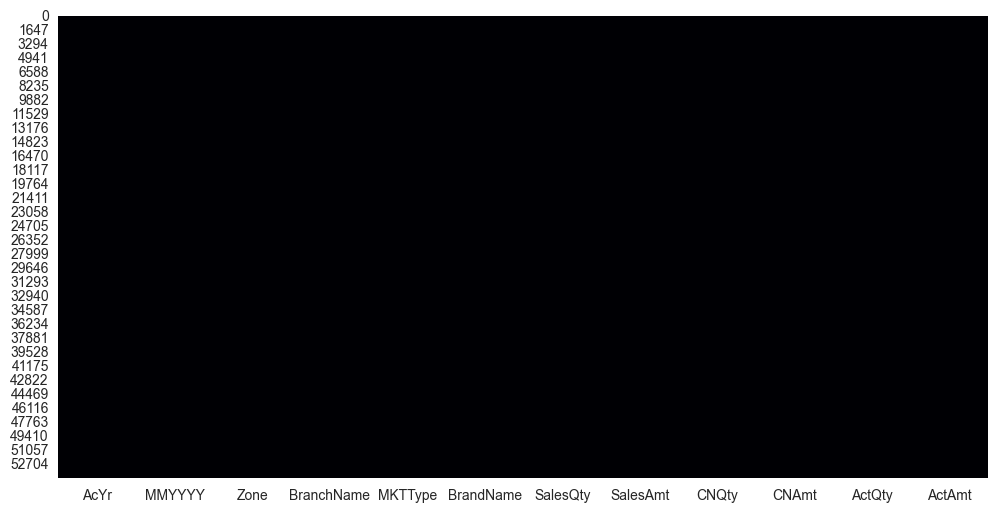

In [12]:
sns.heatmap(df.isnull(),cmap = 'magma',cbar = False);

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54321 entries, 0 to 54320
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AcYr        54321 non-null  object 
 1   MMYYYY      54321 non-null  object 
 2   Zone        54321 non-null  object 
 3   BranchName  54321 non-null  object 
 4   MKTType     54321 non-null  object 
 5   BrandName   54321 non-null  object 
 6   SalesQty    54321 non-null  float64
 7   SalesAmt    54321 non-null  float64
 8   CNQty       54321 non-null  float64
 9   CNAmt       54321 non-null  float64
 10  ActQty      54321 non-null  int64  
 11  ActAmt      54321 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 5.0+ MB


In [14]:
# Select only MMYYYY and ActAmt columns for ARIMA
df = df[["MMYYYY","ActAmt"]]
df.head()


,MMYYYY,ActAmt
0,2020-04,16755.29
1,2020-04,199176.25
2,2020-04,5454.50
3,2020-04,55941.00
4,2020-04,61072.20


In [15]:
df.tail()

,MMYYYY,ActAmt
54316,2025-10,22909.6
54317,2025-10,27857.6
54318,2025-10,848.7
54319,2025-10,10957.5
54320,2025-10,1671.5


In [16]:
df['MMYYYY']=pd.to_datetime(df['MMYYYY'])

In [17]:
df.set_index("MMYYYY",inplace=True)

In [18]:
df.head()

,ActAmt
MMYYYY,
2020-04-01,16755.29
2020-04-01,199176.25
2020-04-01,5454.50
2020-04-01,55941.00
2020-04-01,61072.20


In [19]:
df.describe()

,ActAmt
count,5.432100e+04
mean,1.228134e+05
std,5.182754e+05
min,-1.594199e+05
25%,6.171600e+03
50%,2.411152e+04
75%,7.163700e+04
max,4.640774e+07


<Axes: xlabel='MMYYYY'>

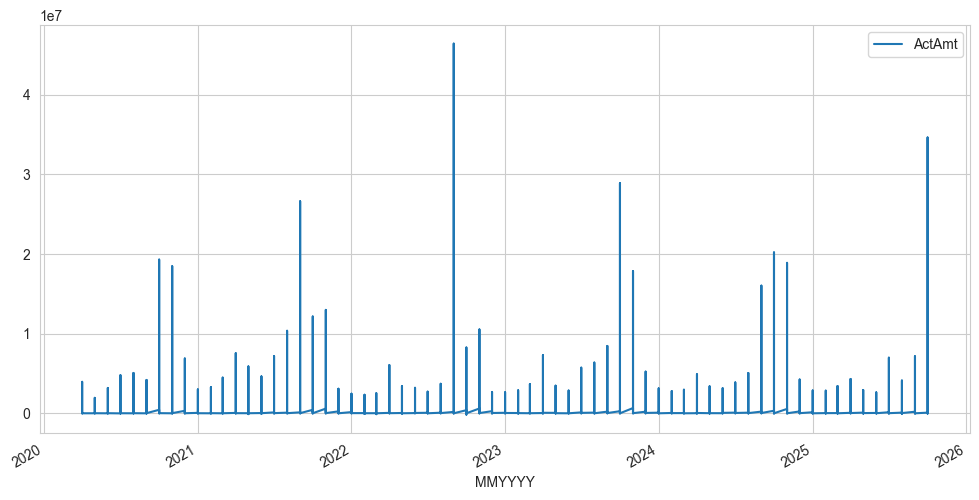

In [20]:
df.plot()

In [21]:
def test_stationarity(timeseries):
    #Determing rolling statistics
    MA = timeseries.rolling(window=12).mean()
    MSTD = timeseries.rolling(window=12).std()

    #Plot rolling statistics:
    plt.figure(figsize=(15,5))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(MA, color='red', label='Rolling Mean')
    std = plt.plot(MSTD, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

In [22]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
        
    with plt.style.context(style):    
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        
        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

<Axes: xlabel='MMYYYY'>

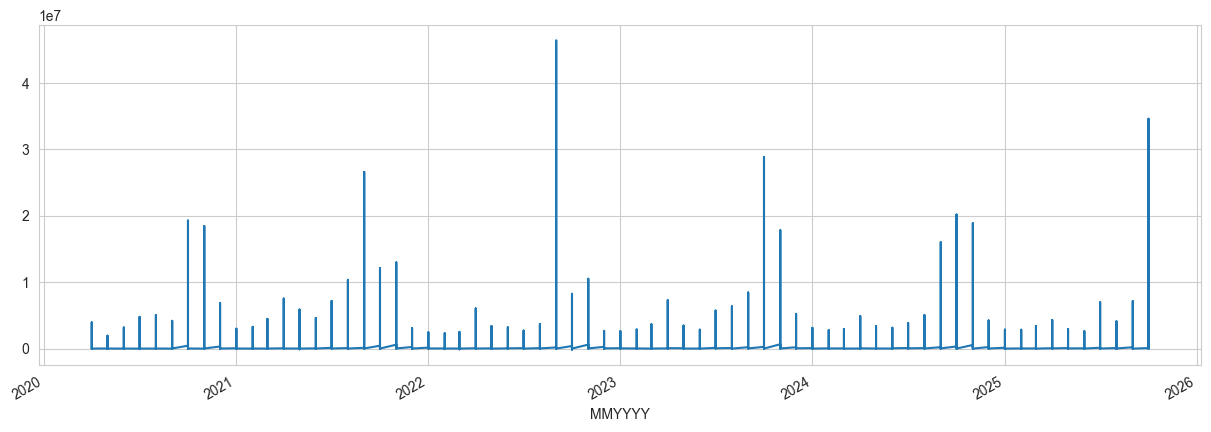

In [23]:
plt.figure(figsize = (15,5))
df['ActAmt'].plot()

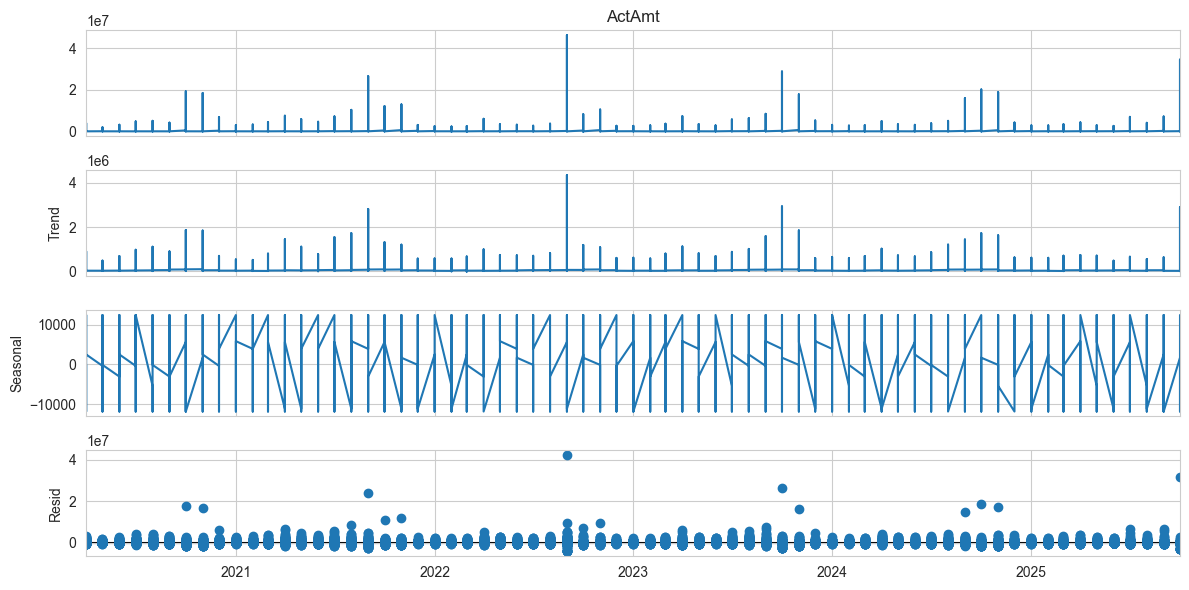

In [24]:
dec = sm.tsa.seasonal_decompose(df['ActAmt'],period = 12, model = 'additive').plot()
plt.show()

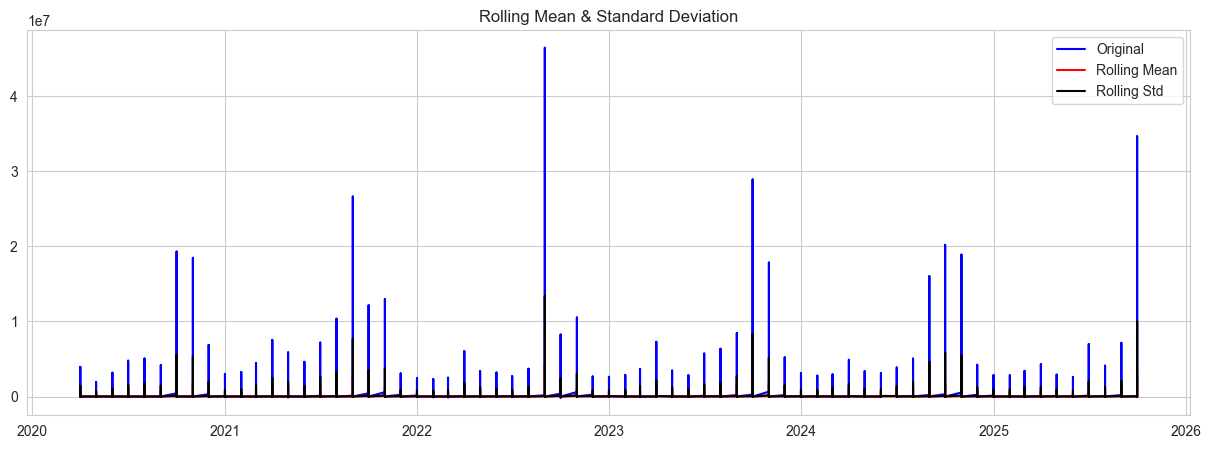

Results of Dickey-Fuller Test:
Test Statistic                   -21.450586
p-value                            0.000000
#Lags Used                        52.000000
Number of Observations Used    54268.000000
Critical Value (1%)               -3.430471
Critical Value (5%)               -2.861593
Critical Value (10%)              -2.566798
dtype: float64


In [25]:
test_stationarity(df['ActAmt'])

In [26]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
        
    with plt.style.context(style):    
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        
        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

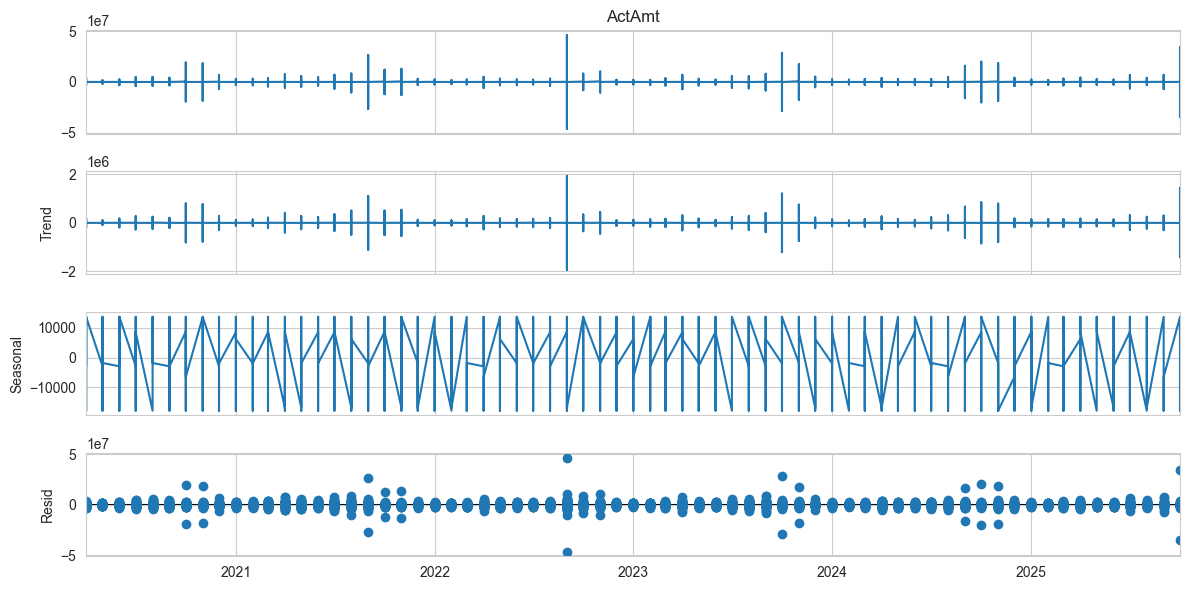

In [28]:
data_diff = df['ActAmt'].diff()
data_diff = data_diff.dropna()

dec = sm.tsa.seasonal_decompose(data_diff,period = 12).plot()
plt.show()

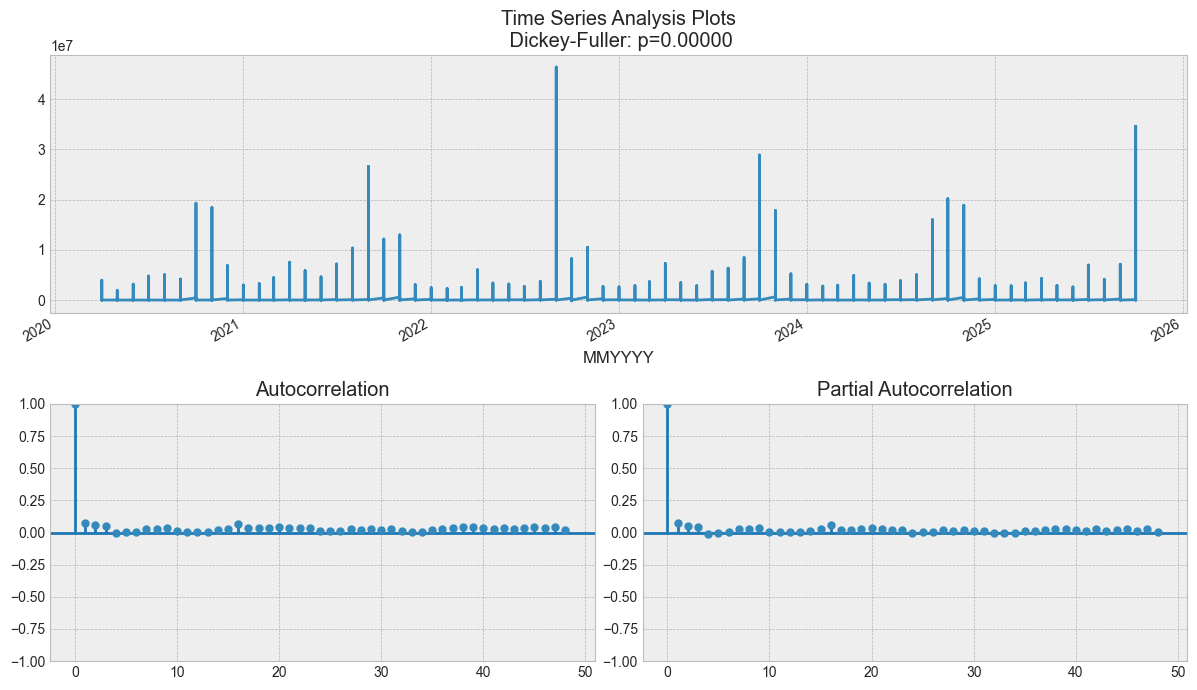

In [29]:
tsplot(df['ActAmt'])

- **ACF** graph provides the correlation between the time series & it's lags. For the above time series, we can observe a positive lowering correlation.
- **PACF** graph provides the correlation between the time series and individual lags. These correlation coefficients are unlike the mutual correlations that are calculated in the presence of other features.
- From the **PACF** graph above, the 1st lag is out of the confidence interval and probably the most significant lag. It probably dictates the pattern for the **ACF** graph where the next lag follows it's previous lag.

In [30]:
model = ARIMA(df['ActAmt'],order = (2,1,2))
model_fit = model.fit()
print(model_fit.summary())

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting au

                               SARIMAX Results                                
Dep. Variable:                 ActAmt   No. Observations:                54321
Model:                 ARIMA(2, 1, 2)   Log Likelihood             -791695.020
Date:                Wed, 18 Feb 2026   AIC                        1583400.040
Time:                        15:49:48   BIC                        1583444.553
Sample:                             0   HQIC                       1583413.930
                              - 54321                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7504      0.308     -2.436      0.015      -1.354      -0.147
ar.L2          0.0398      0.018      2.175      0.030       0.004       0.076
ma.L1         -0.1789      0.308     -0.581      0.5

### In - Sample Forecasting :

- **In - Sample Forecasting** : Model forecasts values for the existing data points of the time series. It is similar to the train - test format for regression or classification problems. 
- We divide the data into train and test dataset. We reserve the last 30 elements for the test dataset and the remaining for the train dataset.
- For this **In - Sample Forecasting**, we use the **rolling** forecast method i.e we predict or forecast a single value and use this predicted value again for model fitting for predicting the next value.
- Test RMSE value is quite high.
- Presence of seasonality as well as order of the **ARIMA** model might have had an effect on the model performance. We will move on to **Out - Of - Sample Forecasting**.

In [32]:
# Split data into train and test sets (keep last 30 observations for testing)
train_size = len(df) - 30
train, test = df['ActAmt'][0:train_size], df['ActAmt'][train_size:len(df)]

print('\t ARIMA MODEL : In-Sample Forecasting \n')

history = [x for x in train]
predictions = []

for t in range(len(test)):
    try:
        model = ARIMA(history, order=(2,1,2))
        model_fit = model.fit()
        
        output = model_fit.forecast(steps=1)
        yhat = float(output[0])
        predictions.append(yhat)
        
        obs = test.iloc[t]
        history.append(obs)
        
        print('predicted = %f, expected = %f' % (yhat, obs))
    except Exception as e:
        print(f'Error at iteration {t}: {str(e)}')
        break

# Calculate error metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

if predictions:
    mse = mean_squared_error(test[:len(predictions)], predictions)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(test[:len(predictions)], predictions)
    
    print(f'\nModel Performance:')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')


	 ARIMA MODEL : In-Sample Forecasting 



c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


predicted = 15290.642999, expected = 1870.000000
predicted = 15612.973989, expected = 2250.000000
predicted = 14498.073386, expected = 2973.440000
predicted = 15058.988624, expected = -57.210000
predicted = 14050.219227, expected = 13366.720000
predicted = 15230.503718, expected = 3921.990000
predicted = 14107.252128, expected = -1131.400000
predicted = 13939.996665, expected = 1260.190000
predicted = 13565.204994, expected = 12581.250000
predicted = 14369.092463, expected = 4348.540000
predicted = 13547.297029, expected = -108.000000
predicted = 13263.553934, expected = 13405.390000
predicted = 13844.065603, expected = 342.620000
predicted = 12987.106494, expected = -159.430000
predicted = 12709.674156, expected = 2217.750000
predicted = 12671.535054, expected = 56070.000000
predicted = 16273.195794, expected = 1354.000000
predicted = 12961.069370, expected = 2185.600000
predicted = 13089.500938, expected = 5357.000000
predicted = 12902.047630, expected = 11104.000000
predicted = 1334

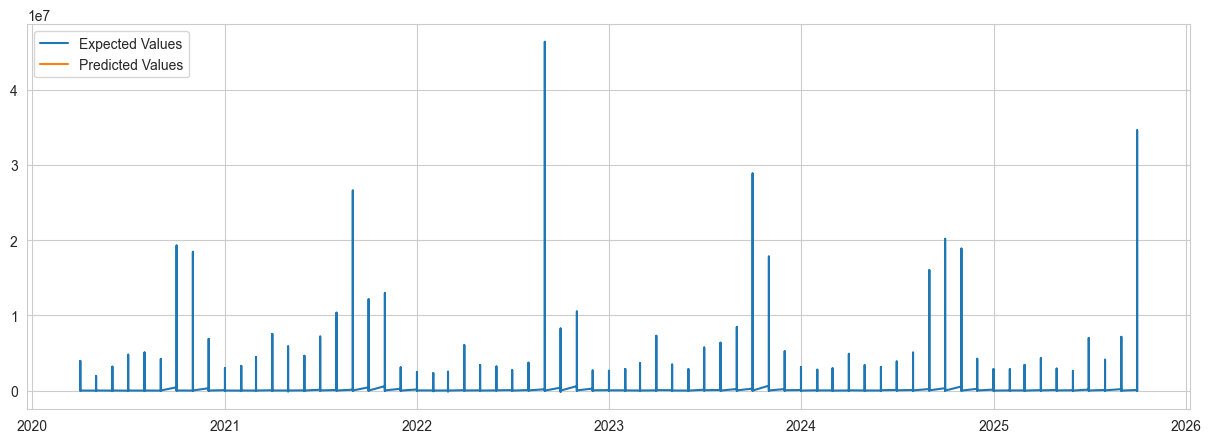

In [33]:
predictions_series = pd.Series(predictions, index = test.index)
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (15,5))

plt.subplot(1,1,1)
plt.plot(df['ActAmt'],label = 'Expected Values')
plt.plot(predictions_series,label = 'Predicted Values');
plt.legend(loc="upper left")
plt.show()

### Out - of - Sample Forecasting :

- **Out - of - Sample Forecasting** : Model forecasts values for the future data points by imputing the datetime index values of the time series.
- We create a new dataframe with the future index values and same columns as the dataframe that we use for model fitting. 
- For this **Out - of - Sample Forecasting**, we use the **rolling** method by using **forecast function** and **predict function**.
- In the **rolling** method, we forecast or predict the next single value, use this predicted value again for model fitting that is then used for predicting the next value.

In [36]:
from pandas.tseries.offsets import DateOffset

# Generate future dates (48 weeks into the future)
future_dates = [df.index[-1] + DateOffset(weeks=x) for x in range(1, 49)]

# Create new dataframe with future dates and same columns as original
df_future = pd.DataFrame(index=future_dates, columns=df.columns)

# Concatenate historical data with future dates
forecast = pd.concat([df, df_future])

# Initialize columns for storing forecast values
forecast['ARIMA_Forecast_Function'] = np.nan
forecast['ARIMA_Predict_Function'] = np.nan

print(f"Forecast dataframe shape: {forecast.shape}")
print(f"Original data points: {len(df)}")
print(f"Future forecast points: {len(df_future)}")
print(f"\nFirst few rows:")
print(forecast.head())
print(f"\nLast few rows:")
print(forecast.tail())


Forecast dataframe shape: (54369, 3)
Original data points: 54321
Future forecast points: 48

First few rows:
               ActAmt  ARIMA_Forecast_Function  ARIMA_Predict_Function
2020-04-01   16755.29                      NaN                     NaN
2020-04-01  199176.25                      NaN                     NaN
2020-04-01    5454.50                      NaN                     NaN
2020-04-01   55941.00                      NaN                     NaN
2020-04-01   61072.20                      NaN                     NaN

Last few rows:
            ActAmt  ARIMA_Forecast_Function  ARIMA_Predict_Function
2026-08-05     NaN                      NaN                     NaN
2026-08-12     NaN                      NaN                     NaN
2026-08-19     NaN                      NaN                     NaN
2026-08-26     NaN                      NaN                     NaN
2026-09-02     NaN                      NaN                     NaN


C:\Users\Asus\AppData\Local\Temp\ipykernel_34504\3007092553.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  forecast = pd.concat([df, df_future])


- We create 2 new columns for storing the values forecasted or predicted into **ARIMA_Forecast_Function** and **ARIMA_Predict_Function**.

**Forcast Function**

In [37]:
ARIMA_history_f = [x for x in train]
f1 = []

print('Generating ARIMA forecasts for future periods...\n')

for t in range(len(df_future)):
    try:
        model = ARIMA(ARIMA_history_f, order=(2,1,2))
        model_fit = model.fit()
        
        # Forecast next value
        output = model_fit.forecast(steps=1)
        forecast_value = float(output[0])
        
        ARIMA_history_f.append(forecast_value)
        f1.append(forecast_value)
        
        print(f'Period {t+1}: Forecasted value = {forecast_value:.2f}')
    except Exception as e:
        print(f'Error at forecast period {t}: {str(e)}')
        break

# Fill the forecast column with predicted values
for i in range(len(f1)):
    forecast.iloc[len(df) + i, forecast.columns.get_loc('ARIMA_Forecast_Function')] = f1[i]

print(f'\nGenerated {len(f1)} forecast values')
print(forecast.tail(10))


Generating ARIMA forecasts for future periods...



c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Period 1: Forecasted value = 15290.64
Period 2: Forecasted value = 16561.45
Period 3: Forecasted value = 15688.04
Period 4: Forecasted value = 16394.07
Period 5: Forecasted value = 15829.48
Period 6: Forecasted value = 16281.26
Period 7: Forecasted value = 15919.76
Period 8: Forecasted value = 16209.02
Period 9: Forecasted value = 15977.56
Period 10: Forecasted value = 16162.77
Period 11: Forecasted value = 16014.57
Period 12: Forecasted value = 16133.16
Period 13: Forecasted value = 16038.27
Period 14: Forecasted value = 16114.19
Period 15: Forecasted value = 16053.44
Period 16: Forecasted value = 16102.05
Period 17: Forecasted value = 16063.15
Period 18: Forecasted value = 16094.28
Period 19: Forecasted value = 16069.37
Period 20: Forecasted value = 16089.30
Period 21: Forecasted value = 16073.36
Period 22: Forecasted value = 16086.12
Period 23: Forecasted value = 16075.91
Period 24: Forecasted value = 16084.08
Period 25: Forecasted value = 16077.54
Period 26: Forecasted value = 1608

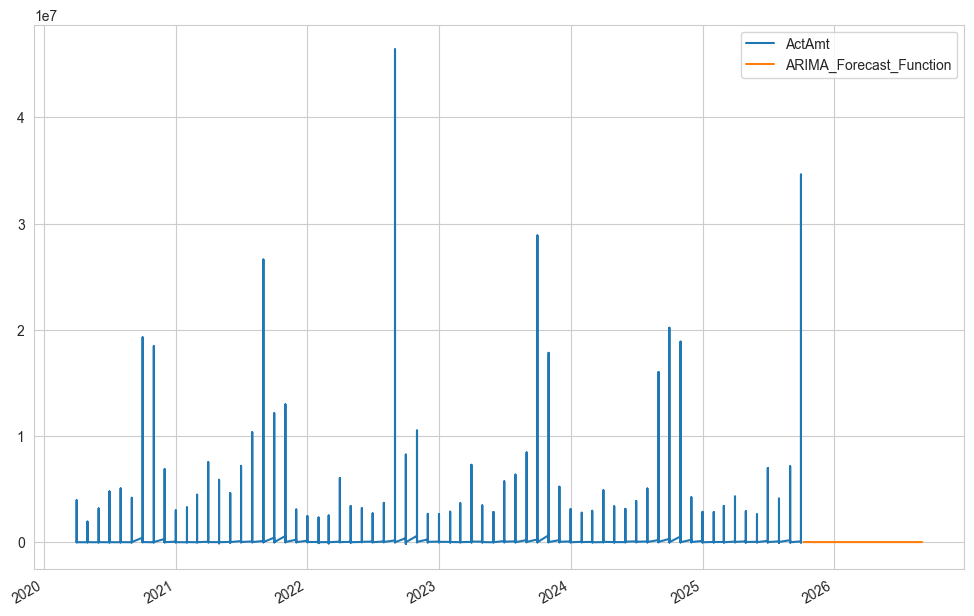

In [39]:
forecast[['ActAmt','ARIMA_Forecast_Function']].plot(figsize = (12,8));